In [62]:
import pypsa

network = pypsa.Network(
    "results/JP_po2023_cy2020_wy2023_dc2023/networks/elec_s_100_ec_lv1_Co2L-1h.nc"
)

network

INFO:pypsa.io:Imported network elec_s_100_ec_lv1_Co2L-1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


PyPSA Network
Components:
 - Bus: 100
 - Carrier: 19
 - Generator: 548
 - GlobalConstraint: 2
 - Line: 181
 - Link: 12
 - Load: 96
 - StorageUnit: 59
Snapshots: 8760

In [63]:
generation_by_carrier_gwh = (
    network.generators_t.p.groupby(network.generators.carrier, axis=1).sum().sum()
    / 1000
)

print(generation_by_carrier_gwh)

carrier
CCGT             197229.379134
coal             358914.840973
geothermal          763.152533
load shedding     17793.168688
nuclear          257446.904301
offwind-ac         3141.976392
offwind-dc            0.000000
oil                4027.124020
onwind             8946.372644
ror                2159.589353
solar             97454.893085
dtype: float64


/tmp/ipykernel_8230/86088659.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(network.generators.carrier, axis=1)


In [64]:
generation_by_carrier_gwh = (
    network.storage_units_t.p.groupby(network.storage_units.carrier, axis=1).sum().sum()
    / 1000
)

print(generation_by_carrier_gwh)

carrier
PHS         -6.527067
hydro    39296.166749
dtype: float64


/tmp/ipykernel_8230/3079683400.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(network.storage_units.carrier, axis=1)


In [65]:
network.generators.groupby("carrier").p_nom_opt.sum().sort_values(ascending=False)

carrier
load shedding    205273.448049
solar             87027.185158
CCGT              68620.894280
coal              49890.000000
nuclear           39219.131091
oil               24985.538106
onwind             5183.677857
offwind-ac         1296.000000
ror                1235.000000
geothermal           87.800000
offwind-dc            0.000000
Name: p_nom_opt, dtype: float64

In [66]:
network.generators.groupby("carrier").p_nom.sum().sort_values(ascending=False)

carrier
load shedding    205273.448049
solar             87027.185158
CCGT              68620.894280
coal              49890.000000
nuclear           39219.131091
oil               24985.538106
onwind             5183.677857
offwind-ac         1296.000000
ror                1235.000000
geothermal           87.800000
offwind-dc            0.000000
Name: p_nom, dtype: float64

In [67]:
network.storage_units.groupby("carrier").p_nom_opt.sum()

carrier
PHS      26787.474406
hydro    15008.501274
Name: p_nom_opt, dtype: float64

In [68]:
network.storage_units.groupby("carrier").p_nom.sum()

carrier
PHS      26787.474406
hydro    15008.501274
Name: p_nom, dtype: float64

In [69]:
(
    network.generators.groupby("carrier")
    .p_nom.sum()
    .drop("load shedding", errors="ignore")
    .sum()
    + network.storage_units.groupby("carrier").p_nom.sum()
)

carrier
PHS      304332.700896
hydro    292553.727764
Name: p_nom, dtype: float64

In [70]:
(
    network.generators.groupby("carrier")
    .p_nom_opt.sum()
    .drop("load shedding", errors="ignore")
    .sum()
    + network.storage_units.groupby("carrier").p_nom_opt.sum()
)

carrier
PHS      304332.700896
hydro    292553.727764
Name: p_nom_opt, dtype: float64

In [71]:
total_generation_gwh = network.generators_t.p.sum().sum() / 1e6
total_demand_gwh = network.loads_t.p.sum().sum() / 1e6

print("Total Generation (GWh):", total_generation_gwh)
print("Total Demand (GWh):", total_demand_gwh)

Total Generation (GWh): 947.8774011222127
Total Demand (GWh): 987.1670407901753


In [72]:
# Total demand for each timestamp
total_load = network.loads_t.p.sum(axis=1)

# Monthly demand (GWh)
monthly_demand_gwh = total_load.groupby(total_load.index.strftime("%B")).sum() / 1000

print(monthly_demand_gwh)

snapshot
April        71933.830143
August       98182.984162
December     83190.543416
February     80251.636557
January      90273.102684
July         94291.857231
June         78114.721105
March        78923.257473
May          74635.666105
November     73938.131774
October      75249.799154
September    88181.510986
dtype: float64


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


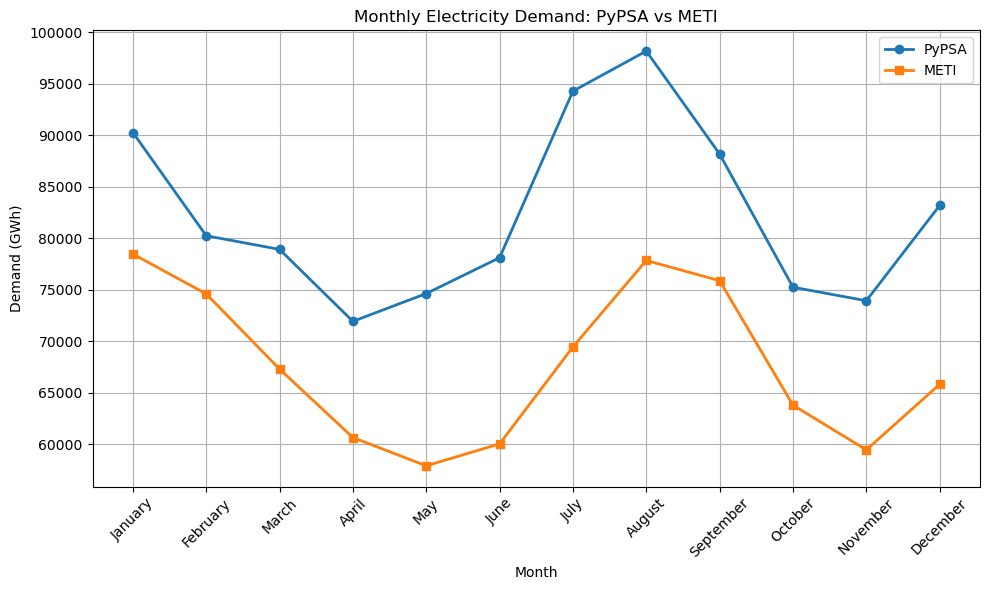

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# PyPSA monthly demand (GWh)
# -----------------------------
total_load = network.loads_t.p.sum(axis=1)

monthly_demand_gwh = total_load.groupby(total_load.index.strftime("%B")).sum() / 1000

# Desired month order
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

monthly_demand_gwh = monthly_demand_gwh.reindex(month_order)

# -----------------------------
# METI monthly demand
# -----------------------------
meti = pd.read_excel("METI_Demand_2023.xlsx", sheet_name="2023_Annual")

# Excel row 53 -> pandas index 52
meti_monthly = meti.iloc[47, 1:13].astype(float) / 1000  # Convert to GWh

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(month_order, monthly_demand_gwh.values, marker="o", linewidth=2, label="PyPSA")

plt.plot(month_order, meti_monthly.values, marker="s", linewidth=2, label="METI")

plt.xlabel("Month")
plt.ylabel("Demand (GWh)")
plt.title("Monthly Electricity Demand: PyPSA vs METI")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [74]:
import pypsa
import geopandas as gpd
import pandas as pd

network = pypsa.Network("networks/JP_po2023_cy2020_wy2023_dc2023_hs2023/elec_s.nc")

# Annual demand of each load (MWh)
annual_load = network.loads_t.p_set.sum(axis=0)

# Load table
load_df = network.loads.copy()

# Add annual demand
load_df["Annual_Demand_MWh"] = annual_load

# Add bus coordinates
load_df["x"] = load_df["bus"].map(network.buses["x"])
load_df["y"] = load_df["bus"].map(network.buses["y"])

print(load_df.head())
print("Total demand GWh:", load_df["Annual_Demand_MWh"].sum() / 1e6)

INFO:pypsa.io:Imported network elec_s.nc has buses, carriers, generators, lines, links, loads, storage_units


       bus carrier type  p_set  q_set  sign  Annual_Demand_MWh         x  \
Load                                                                       
1000  1000                 0.0    0.0  -1.0      433348.288996  139.9211   
1003  1003                 0.0    0.0  -1.0      105093.767841  140.9903   
1004  1004                 0.0    0.0  -1.0       95767.251618  141.9377   
1006  1006                 0.0    0.0  -1.0       60327.218572  141.8664   
1009  1009                 0.0    0.0  -1.0      209016.856593  140.8415   

            y  
Load           
1000  36.7406  
1003  37.2643  
1004  39.6438  
1006  39.2730  
1009  36.9827  
Total demand GWh: 987.1670407901753


In [75]:
import pandas as pd
import geopandas as gpd

# -----------------------------
# 1. Annual demand from PyPSA
# -----------------------------

# IMPORTANT: use p_set, not p
annual_load = network.loads_t.p_set.sum(axis=0)

load_df = network.loads.copy()

# Add annual demand
load_df["Annual_Demand_MWh"] = annual_load


# -----------------------------
# 2. Aggregate loads by bus
# -----------------------------

bus_demand = load_df.groupby("bus")["Annual_Demand_MWh"].sum().reset_index()

# MWh -> GWh
bus_demand["Annual_Demand_GWh"] = bus_demand["Annual_Demand_MWh"] / 1000


# Add bus coordinates
bus_demand = bus_demand.merge(
    network.buses[["x", "y"]], left_on="bus", right_index=True, how="left"
)


# -----------------------------
# 3. Convert buses to GeoDataFrame
# -----------------------------

bus_gdf = gpd.GeoDataFrame(
    bus_demand, geometry=gpd.points_from_xy(bus_demand.x, bus_demand.y), crs="EPSG:4326"
)


# -----------------------------
# 4. Read Japan prefectures
# -----------------------------

pref = gpd.read_file("japan_prefectures_2023.geojson")

pref = pref.to_crs(bus_gdf.crs)


# -----------------------------
# 5. Assign buses to prefectures
# -----------------------------

joined = gpd.sjoin(bus_gdf, pref, how="left", predicate="within")


# -----------------------------
# 6. Fix unmatched bus
# -----------------------------

missing = joined[joined["prefecture"].isna()]

print("Buses without prefecture:", len(missing))

if len(missing) > 0:

    print(missing[["bus", "x", "y", "Annual_Demand_GWh"]])

    # Bus 990 lies on Aichi boundary
    joined.loc[joined["prefecture"].isna(), "prefecture"] = "Aichi"


# -----------------------------
# 7. Aggregate demand by prefecture
# -----------------------------

prefecture_demand = (
    joined.groupby("prefecture")["Annual_Demand_GWh"].sum().reset_index()
)


print("\nPrefecture demand:")
print(prefecture_demand)


# -----------------------------
# 8. Conservation check
# -----------------------------

original_total = bus_gdf["Annual_Demand_GWh"].sum()

pref_total = prefecture_demand["Annual_Demand_GWh"].sum()

print("\nOriginal PyPSA demand:")
print(original_total / 1000, "TWh")

print("After prefecture allocation:")
print(pref_total / 1000, "TWh")

print("Difference:", (original_total - pref_total) / 1000, "TWh")


# -----------------------------
# 9. Save
# -----------------------------

prefecture_demand.to_csv("PyPSA_Prefecture_Annual_Demand.csv", index=False)

Buses without prefecture: 1
      bus         x        y  Annual_Demand_GWh
1139  990  136.9398  34.8354        1213.294897

Prefecture demand:
   prefecture  Annual_Demand_GWh
0       Aichi       56336.368899
1       Akita        7495.543086
2      Aomori        8613.816538
3       Chiba       42895.380315
4       Ehime       10781.044723
5       Fukui       23546.914824
6     Fukuoka       33694.208492
7   Fukushima       12532.447094
8        Gifu       13903.874048
9       Gunma       18439.194798
10  Hiroshima       16009.929969
11   Hokkaido       25249.974007
12      Hyogo       29210.415866
13    Ibaraki       30403.970393
14   Ishikawa        7004.534692
15      Iwate        8204.279915
16     Kagawa        6456.169636
17  Kagoshima        8067.139285
18   Kanagawa       68181.740651
19      Kochi        2281.554249
20   Kumamoto       10301.308127
21      Kyoto       30197.990056
22        Mie       14762.433347
23     Miyagi       15403.777360
24   Miyazaki        7080.75002

In [76]:
import pandas as pd

# -----------------------------
# Read PyPSA prefecture demand
# -----------------------------
pypsa = pd.read_csv("PyPSA_Prefecture_Annual_Demand.csv")

# -----------------------------
# Read METI annual demand
# -----------------------------
meti = pd.read_excel("METI_Demand_2023.xlsx", sheet_name="2023_Annual")

# Keep only prefecture name and annual demand (Column N)
meti = meti.iloc[:47, [0, 13]].copy()
meti.columns = ["prefecture", "METI_Annual_Demand_GWh"]

# Convert from 1,000 kWh to GWh
meti["METI_Annual_Demand_GWh"] = meti["METI_Annual_Demand_GWh"] / 1000

# Clean prefecture names
meti["prefecture"] = (
    meti["prefecture"]
    .astype(str)
    .str.replace(" Prefecture", "", regex=False)
    .str.replace(" prefecture", "", regex=False)
    .str.strip()
)

# -----------------------------
# Merge (keep all METI prefectures)
# -----------------------------
comparison = meti.merge(pypsa, on="prefecture", how="left")

# Replace missing PyPSA values with 0
comparison["Annual_Demand_GWh"] = comparison["Annual_Demand_GWh"].fillna(0)

# Rename PyPSA column
comparison = comparison.rename(columns={"Annual_Demand_GWh": "PyPSA_Annual_Demand_GWh"})

# Save
comparison.to_csv("PyPSA_vs_METI_Prefecture_Annual_Demand.csv", index=False)

print(comparison)
print("\nSaved as PyPSA_vs_METI_Prefecture_Annual_Demand.csv")

   prefecture  METI_Annual_Demand_GWh  PyPSA_Annual_Demand_GWh
0       Aichi            56153.086513             56336.368899
1       Akita             6899.493835              7495.543086
2      Aomori             7788.967570              8613.816538
3       Chiba            34435.495846             42895.380315
4       Ehime             8273.940712             10781.044723
5       Fukui             7162.081977             23546.914824
6     Fukuoka            30252.628847             33694.208492
7   Fukushima            14717.725372             12532.447094
8        Gifu            14599.173070             13903.874048
9       Gunma            15028.847736             18439.194798
10  Hiroshima            19157.097359             16009.929969
11   Hokkaido            27909.947837             25249.974007
12      Hyogo            36924.904082             29210.415866
13    Ibaraki            22809.109209             30403.970393
14   Ishikawa             8960.673867              7004

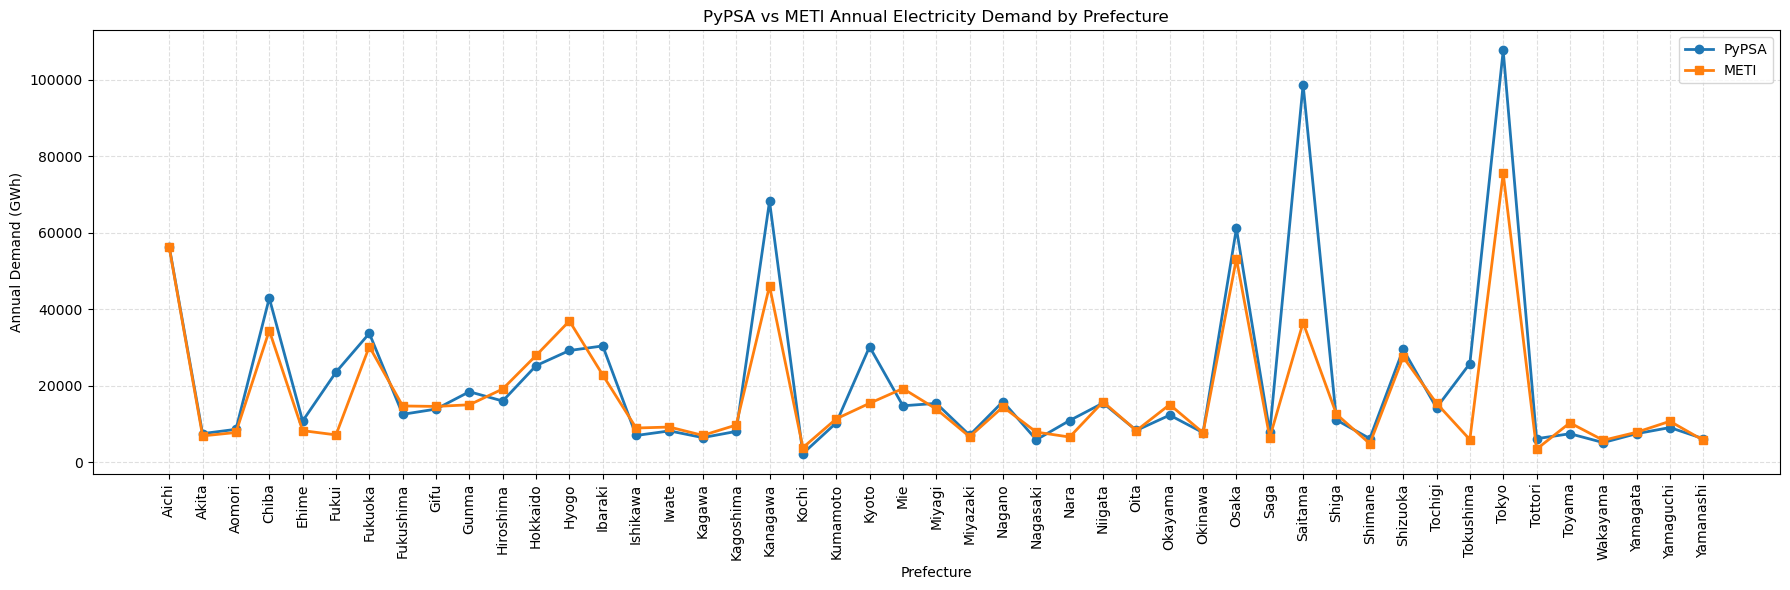

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

# Read comparison file
df = pd.read_csv("PyPSA_vs_METI_Prefecture_Annual_Demand.csv")

# Sort alphabetically by prefecture
df = df.sort_values("prefecture")

# Plot
plt.figure(figsize=(18, 6))

plt.plot(
    df["prefecture"],
    df["PyPSA_Annual_Demand_GWh"],
    marker="o",
    linewidth=2,
    label="PyPSA",
)

plt.plot(
    df["prefecture"],
    df["METI_Annual_Demand_GWh"],
    marker="s",
    linewidth=2,
    label="METI",
)

plt.xticks(rotation=90)
plt.xlabel("Prefecture")
plt.ylabel("Annual Demand (GWh)")
plt.title("PyPSA vs METI Annual Electricity Demand by Prefecture")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.show()

/home/goli-vamsi-priya/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


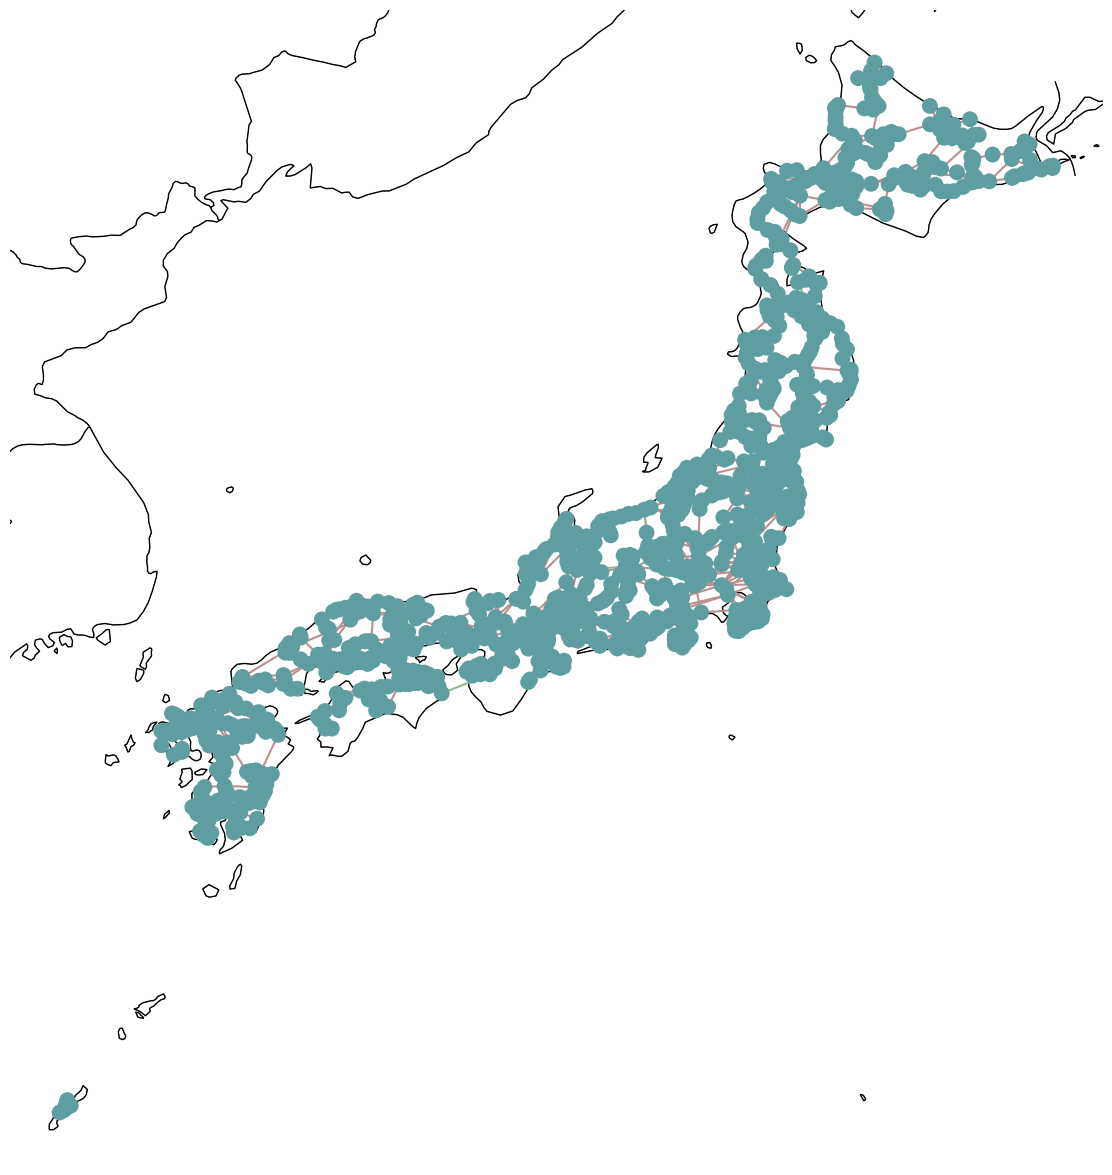

In [78]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={"projection": ccrs.PlateCarree()})

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)

# Plot network
network.plot(ax=ax, geomap=True)

plt.show()

/home/goli-vamsi-priya/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


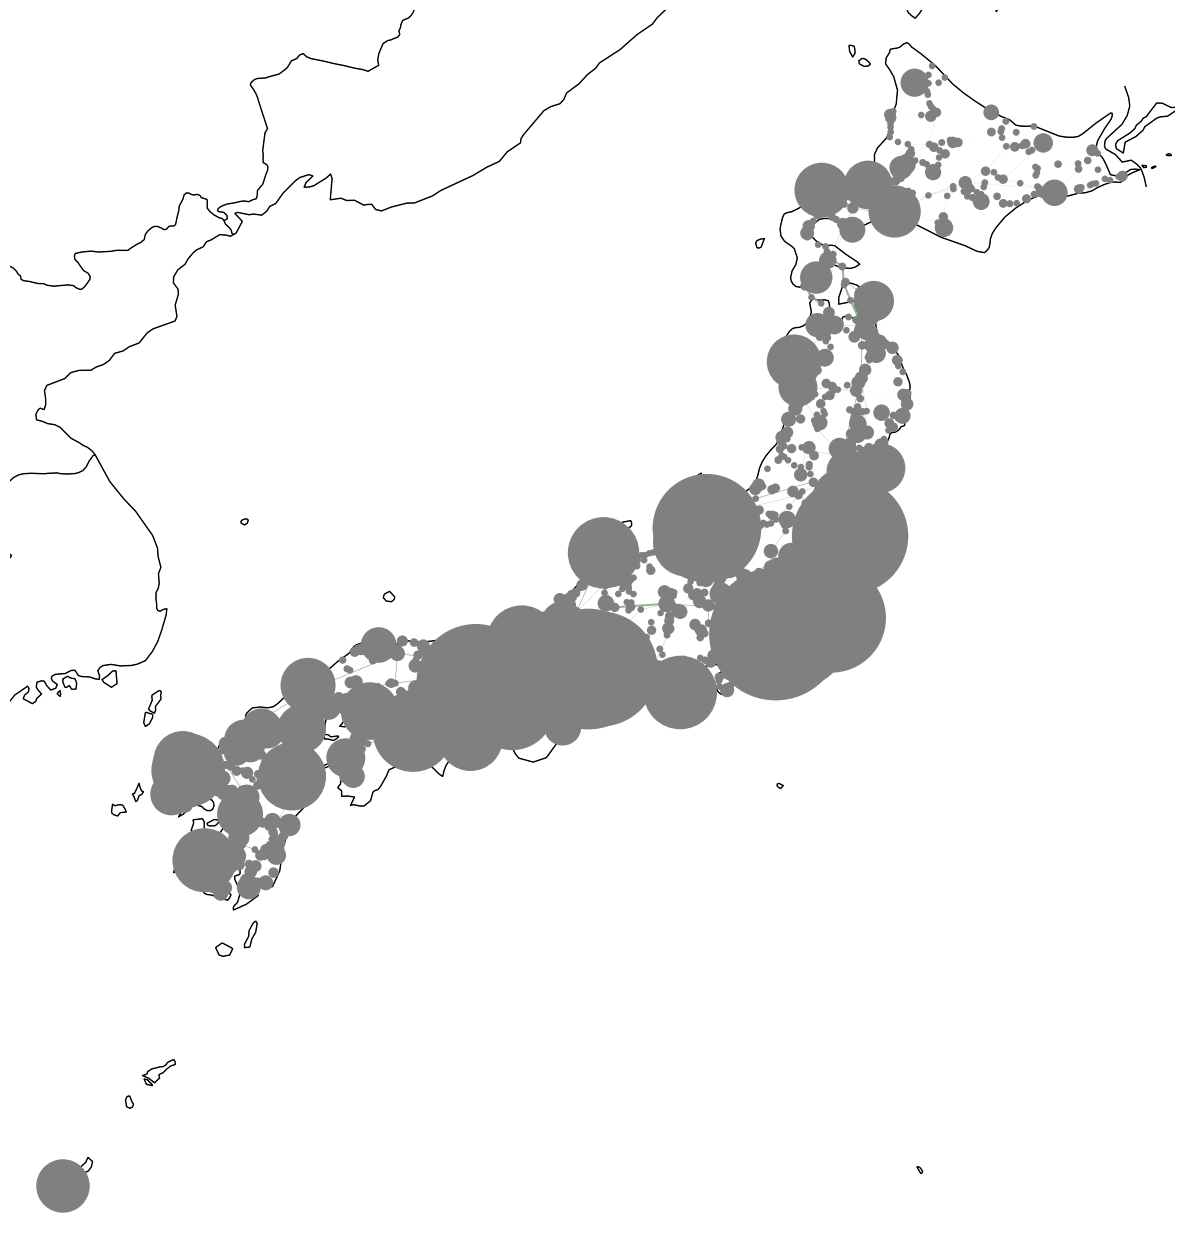

In [79]:
import pypsa
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


fig, ax = plt.subplots(figsize=(16, 16), subplot_kw={"projection": ccrs.PlateCarree()})

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)

network.plot(
    ax=ax,
    bus_sizes=network.generators.groupby("bus").p_nom.sum() / 10000,
    bus_colors="gray",
    line_widths=network.lines.s_nom / 10000,
)

plt.show()